# Assignment 2:

## Storyline: How Robbery Incidents Have Evolved in San Francisco (2009–2019)

## One time-series: Calendar plot 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv('../Assignment-1/Data/SF_Crime_Data_Focus_Cleaned.csv', parse_dates=["Incident Date"])

# 🔹 Filter data for the period 2014-2024
df = df[(df["Incident Date"].dt.year >= 2009) & (df["Incident Date"].dt.year <= 2019)]



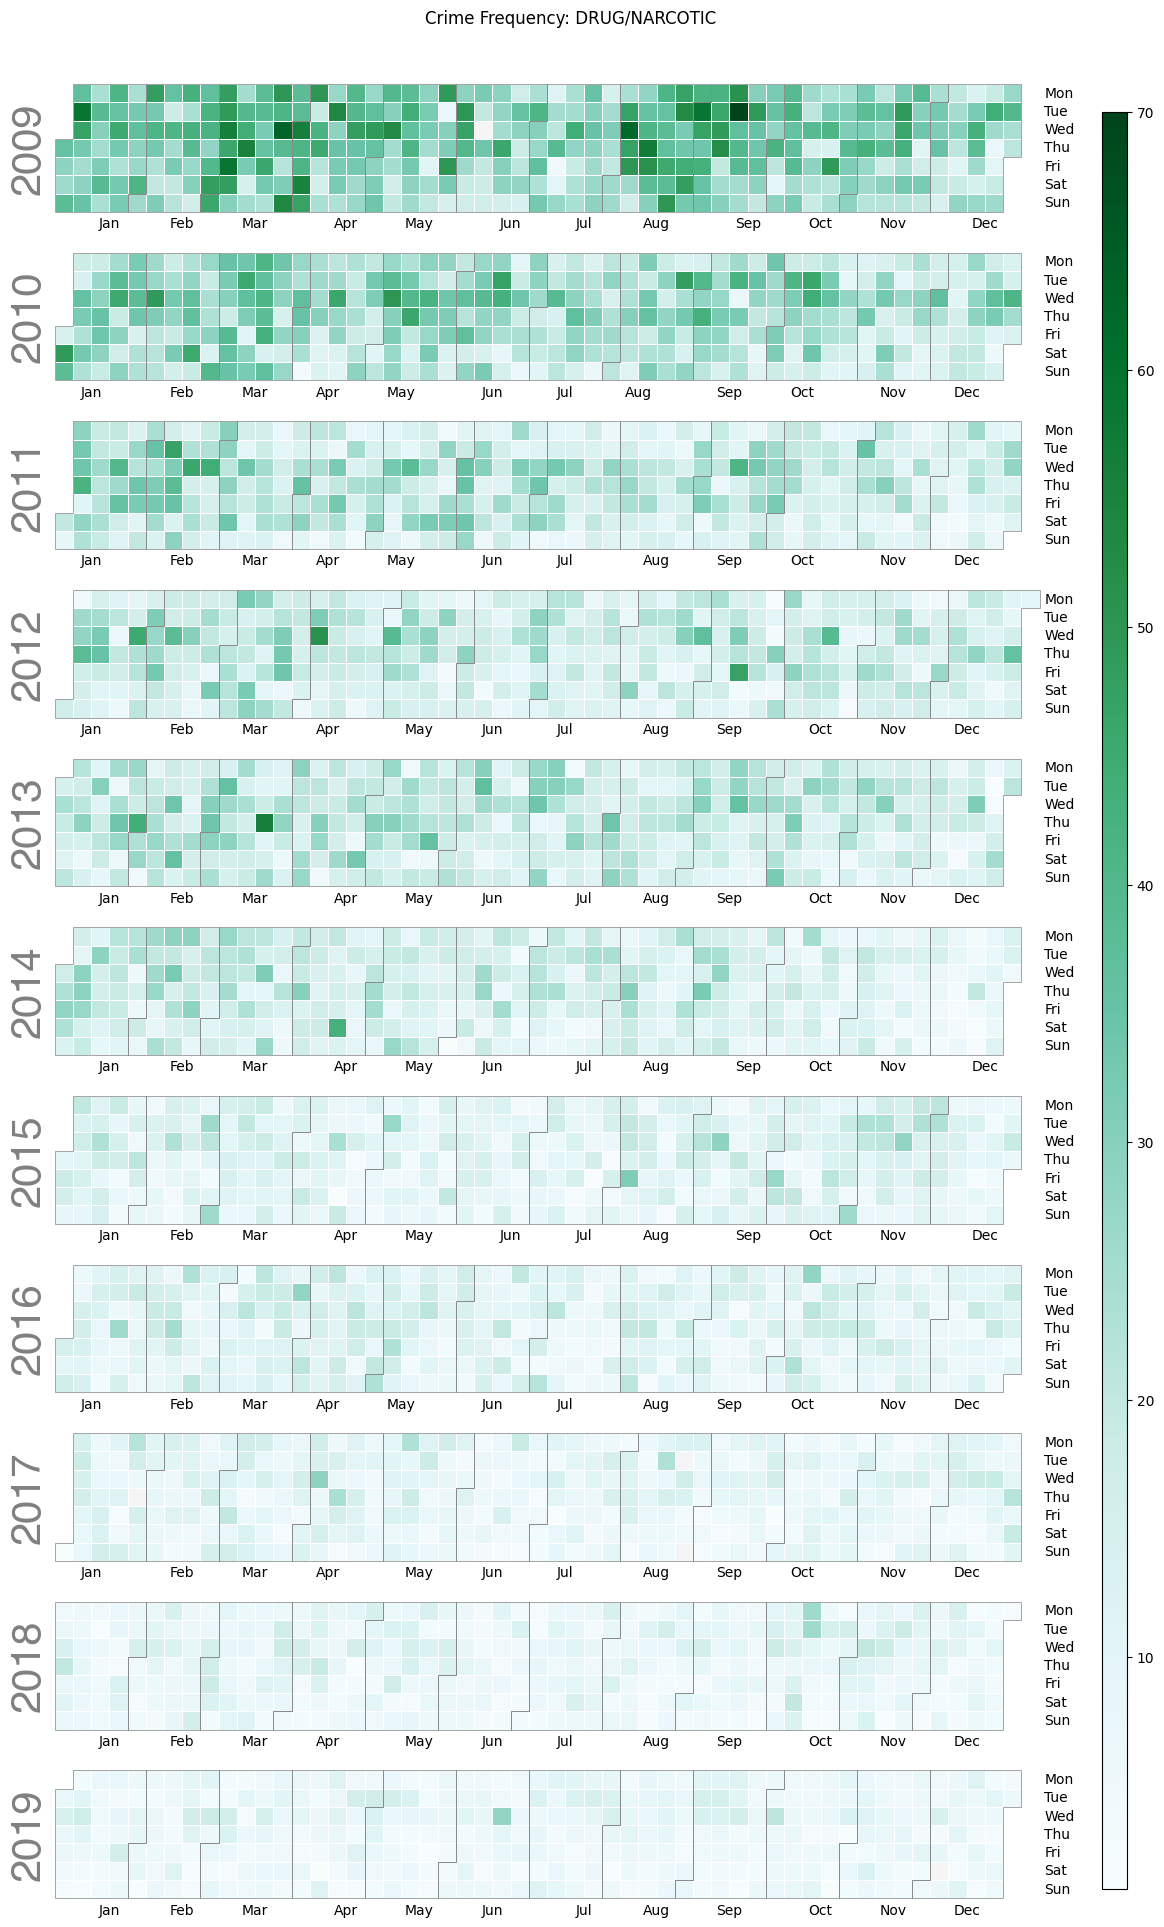

In [7]:
import calplot
crime_type = "DRUG/NARCOTIC" 

# 🔹 Aggregate daily counts
crime_daily = df[df["Incident Category"] == crime_type].groupby("Incident Date").size()

# 🔹 Plot calendar heatmap and save the figure
# Create the calendar plot
fig, axes = calplot.calplot(
    crime_daily, 
    cmap="BuGn", 
    colorbar=True, 
    suptitle=f"Crime Frequency: {crime_type}", 
    linewidth=0.5, 
    dropzero=True, 
    edgecolor="gray"
)

# Save the figure before showing it
fig.savefig("calendar_plot.png", dpi=300, bbox_inches='tight')


# 🔹 Then show
plt.show()



### Calendar Plot: Drug/Narcotic Crimes (2009–2019)

The calendar visualizes a detailed year-by-year overview of drug/narcotic-related incidents in San Francisco from 2009 to 2019. Each row corresponds to a calendar year, with individual squares representing single days. The color intensity indicates the frequency of incidents on the day where darker green signifies a higher number of incidents.

What stands out immediately is the high density of dark green cells in 2009, especially concentrated in certain periods such as early spring and mid-summer. This suggests that drug-related crime was not only more prevalent but also more consistently reported throughout the calendar year.

As we move downward through the years, the green gradually fades. From around 2014 onward, the number of dark-colored cells drops significantly. By 2018–2019, the calendar is largely filled with pale or nearly white squares — a visual confirmation of the steady and substantial decline in drug/narcotic offenses over the decade.

## One map: Heatmap over hotspots for drugs/narcotics in San Francisco

In [8]:
import folium
from folium.plugins import HeatMap

# 🔹 Filter Drug/Narcotic incidents
df_DrugsAndNarcotics = df[df["Incident Category"] == "DRUG/NARCOTIC"].copy()

# 🔹 Initialize the map centered on San Francisco
sf_map = folium.Map(location=[37.7749, -122.4194], zoom_start=12)

# 🔹 Extract coordinates into list format
heat_data = df_DrugsAndNarcotics[["Latitude", "Longitude"]].dropna().values.tolist()

# 🔹 Add HeatMap layer
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(sf_map)

# 🔹 Add all police districts as labeled markers
district_labels = {
    "BAYVIEW": [37.7294, -122.3928],
    "CENTRAL": [37.7985, -122.4078],
    "INGLESIDE": [37.7210, -122.4478],
    "MISSION": [37.7599, -122.4148],
    "NORTHERN": [37.7866, -122.4376],
    "PARK": [37.7680, -122.4524],
    "RICHMOND": [37.7799, -122.4862],
    "SOUTHERN": [37.7786, -122.4059],
    "TARAVAL": [37.7433, -122.4750],
    "TENDERLOIN": [37.7831, -122.4170]
}

for name, coords in district_labels.items():
    folium.Marker(
        location=coords,
        popup=name.title(),
        icon=folium.Icon(color='darkblue')
    ).add_to(sf_map)

# 🔹 Show the map

sf_map.save("interactive_map.html")
sf_map



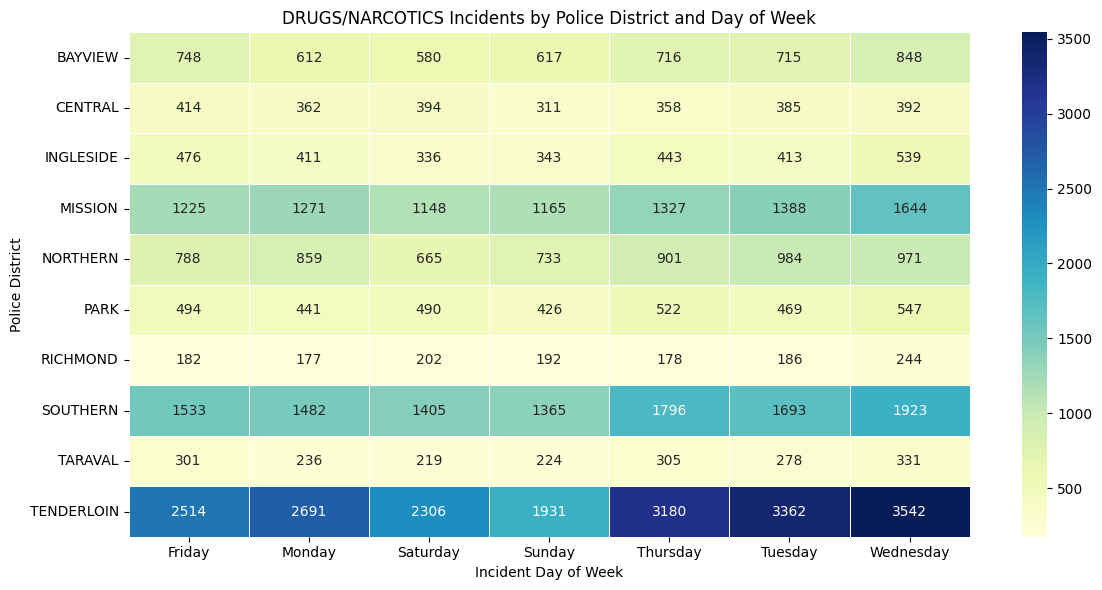

In [9]:
# 🔹 Standardize all district names to uppercase
df_DrugsAndNarcotics['Police District'] = df_DrugsAndNarcotics['Police District'].str.upper()

# 🔹 Remove 'OUT OF SF'
df_DrugsAndNarcotics = df_DrugsAndNarcotics[df_DrugsAndNarcotics['Police District'] != 'OUT OF SF']

# 🔹 Create pivot table
pivot = df_DrugsAndNarcotics.pivot_table(
    index='Police District',
    columns='Incident Day of Week',
    aggfunc='size',
    fill_value=0
)

# 🔹 Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d', linewidths=0.5)

plt.title('DRUGS/NARCOTICS Incidents by Police District and Day of Week')
plt.xlabel('Incident Day of Week')
plt.ylabel('Police District')
plt.tight_layout()
plt.show()


In [16]:
print(df.columns.tolist())


['Incident Date', 'Incident Time', 'Incident Day of Week', 'Incident Category', 'Incident Description', 'Police District', 'Latitude', 'Longitude']


In [20]:
from bokeh.io import output_file, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.transform import dodge
from bokeh.palettes import Category10

output_file("bokeh.html")

# 🔹 Focus categories
categories = ["DRUG/NARCOTIC", "ASSAULT"]

# 🔹 Filter dataset for these categories and clean
filtered_df = df[df["Incident Category"].isin(categories)].copy()
filtered_df["Police District"] = filtered_df["Police District"].str.upper()
filtered_df = filtered_df[filtered_df["Police District"].notna()]

# 🔹 Group by district and category
grouped = filtered_df.groupby(["Police District", "Incident Category"]).size().unstack(fill_value=0)

# 🔹 Sort districts by total incidents (optional)
grouped = grouped.loc[grouped.sum(axis=1).sort_values(ascending=False).index]

# 🔹 Prepare Bokeh data source
districts = grouped.index.tolist()
source = ColumnDataSource(data={
    "district": districts,
    "DRUG/NARCOTIC": grouped["DRUG/NARCOTIC"],
    "ASSAULT": grouped["ASSAULT"]
})

# 🔹 Create the plot
p = figure(
    x_range=districts,
    height=450,
    title="Drug/Narcotic vs Assault Incidents by Police District",
    toolbar_location="above",
    x_axis_label="Police District",
    y_axis_label="Number of Incidents",
    tools="pan,wheel_zoom,box_zoom,reset"
)

# 🔹 Colors
colors = Category10[3]

# 🔹 Add bars
p.vbar(x=dodge("district", -0.15, range=p.x_range), top="DRUG/NARCOTIC", width=0.25,
       source=source, color=colors[0], legend_label="DRUG/NARCOTIC")

p.vbar(x=dodge("district", 0.15, range=p.x_range), top="ASSAULT", width=0.25,
       source=source, color=colors[1], legend_label="ASSAULT")

# 🔹 Add hover tool
hover = HoverTool(tooltips=[
    ("District", "@district"),
    ("Drug Incidents", "@{DRUG/NARCOTIC}"),
    ("Assault Incidents", "@ASSAULT")
])
p.add_tools(hover)

# 🔹 Final styling
p.xaxis.major_label_orientation = 1
p.legend.location = "top_right"
p.legend.click_policy = "mute"

show(p)


While drug-related crimes are concentrated in certain districts, other types like assault show a different distribution — suggesting targeted hotspots for specific offenses. The Tenderloin district shows a higher concentration of drug-related incidents compared to assault, reflecting long-standing issues in the area.

